In [3]:
# replace columns and drop some
# linear regg model (strd & GD)
# svm 
# random forest
# naive bayes
# MLP

In [4]:
%pip install -r ../../requirements.txt

import pandas as pd

Note: you may need to restart the kernel to use updated packages.


In [5]:
toronto_data = pd.read_csv('../data/toronto_real_estate_public_area.csv')

In [6]:
toronto_data.head(3)

,property_id,period,home_type_bucket,status,last_status,home_type,price,list_price,sold_price,list_date,neighbourhood,latitude,longitude,bedrooms,bedrooms_plus,bathrooms,brokerage,images_count,estimated_area_sqft
0,1,sale,CONDO,ACTIVE,PRICE_CHANGE,CONDO,388000.0,388000.0,NaN,2026-04-12T13:29:08.000Z,Waterfront Communities The Island,43.648879,-79.388044,1.0,NaN,1.0,HC REALTY GROUP INC.,46,350.0
1,2,sale,CONDO,ACTIVE,NEW,CONDO,385000.0,385000.0,NaN,2026-05-28T11:31:44.000Z,Moss Park,43.653313,-79.359882,NaN,NaN,1.0,BAKER REAL ESTATE INCORPORATED,24,350.0
2,3,sale,CONDO,ACTIVE,NEW,CONDO,299000.0,299000.0,NaN,2026-06-09T10:35:34.000Z,Church-Yonge Corridor,43.657375,-79.374087,NaN,NaN,1.0,SUPERSTARS REALTY LTD.,25,350.0


In [7]:
# We'll be using sold_price as the target for this model, and won't be using price or list_price as features.

toronto_data = toronto_data.drop(columns=['property_id', 'period', 'brokerage', 'home_type_bucket', 'sold_price', 'list_date', 'bedrooms_plus', 'list_price', 'images_count','status', 'last_status'])

In [8]:
toronto_data

,home_type,price,neighbourhood,latitude,longitude,bedrooms,bathrooms,estimated_area_sqft
0,CONDO,388000.0,Waterfront Communities The Island,43.648879,-79.388044,1.0,1.0,350.0
1,CONDO,385000.0,Moss Park,43.653313,-79.359882,NaN,1.0,350.0
2,CONDO,299000.0,Church-Yonge Corridor,43.657375,-79.374087,NaN,1.0,350.0
3,CONDO,399000.0,Bay Street Corridor,43.661136,-79.385605,1.0,1.0,650.0
4,CONDO,399999.0,South Riverdale,43.657640,-79.350917,1.0,1.0,550.0
...,...,...,...,...,...,...,...,...
9699,CONDO,555000.0,Waterfront Communities C1,43.645958,-79.389873,1.0,1.0,550.0
9700,CONDO,585000.0,Little Portugal,43.642018,-79.423509,2.0,2.0,550.0
9701,CONDO,600000.0,Clairlea Birchmount,43.716540,-79.284514,2.0,2.0,950.0
9702,CONDO,595000.0,Moss Park,43.656969,-79.374122,1.0,1.0,550.0


In [9]:
tud = toronto_data['price'].isnull().sum()
tud

np.int64(0)

In [10]:
toronto_data.isnull().sum()

home_type                0
price                    0
neighbourhood            1
latitude                 0
longitude                0
bedrooms               290
bathrooms               50
estimated_area_sqft    162
dtype: int64

In [11]:
# Renamed column to locality after normalization

toronto_data['locality'] = (
    toronto_data['neighbourhood']
    .dropna()
    .str.lower()
    .str.replace(r'^[a-z0-9]+ - ', '', regex=True)
    .str.replace(r'[-]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [12]:
toronto_data['locality'].isnull().sum()

np.int64(1)

In [13]:
len(toronto_data['locality'].unique())

131

In [14]:
(toronto_data['locality'].value_counts()).sum()

np.int64(9703)

In [15]:
toronto_data = toronto_data.drop(columns=['neighbourhood'])

In [16]:
toronto_data = toronto_data.rename(columns={'bedrooms' : 'beds', 'bathrooms': 'baths', 'estimated_area_sqft': 'area'})

In [17]:
(toronto_data['locality'].value_counts() <= 1).sum()

np.int64(21)

In [18]:
toronto_data['price_per_sqft'] = toronto_data['price'] / toronto_data['area']

/var/folders/qf/wwtn7pd17xzb9r_bmy7p58z80000gn/T/ipykernel_14573/3966877660.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  toronto_data['price_per_sqft'] = toronto_data['price'] / toronto_data['area']


In [19]:
toronto_data.tail(3)

,home_type,price,latitude,longitude,beds,baths,area,locality,price_per_sqft
9701,CONDO,600000.0,43.716540,-79.284514,2.0,2.0,950.0,clairlea birchmount,631.578947
9702,CONDO,595000.0,43.656969,-79.374122,1.0,1.0,550.0,moss park,1081.818182
9703,CONDO,550500.0,43.640144,-79.423917,2.0,2.0,750.0,south parkdale,734.000000


In [20]:
locality_stats = toronto_data.groupby('locality')['locality'].agg('count').sort_values(ascending=False)
locality_stats

locality
waterfront communities c1            859
waterfront communities the island    704
church yonge corridor                665
bay street corridor                  511
niagara                              462
                                    ... 
east york                              1
dorset park                            1
cliffcrest                             1
don valley village                     1
danforth village east york             1
Name: locality, Length: 130, dtype: int64

In [21]:
locality_less_than_2 = locality_stats[locality_stats <= 1]
locality_less_than_2

locality
humberlea pelmo park w5       1
hillcrest village             1
alderwood                     1
morningside                   1
woodbine lumsden              1
milliken                      1
bayview village               1
bathurst manor                1
highland creek                1
crescent town                 1
north j                       1
black creek                   1
west hill                     1
carleton place                1
port perry                    1
tudor ward                    1
east york                     1
dorset park                   1
cliffcrest                    1
don valley village            1
danforth village east york    1
Name: locality, dtype: int64

In [22]:
toronto_data.locality = toronto_data.locality.apply(lambda x: 'other' if x in locality_less_than_2 else x)

In [23]:
len(toronto_data[toronto_data.area / toronto_data.beds < 300])

174

In [24]:
toronto_data.groupby('beds')['area'].describe()

,count,mean,std,min,25%,50%,75%,max
beds,,,,,,,,
1.0,3048.0,611.960302,184.619649,350.0,550.0,650.0,650.0,5000.0
2.0,3226.0,1057.106634,407.265140,350.0,750.0,950.0,1100.0,3874.0
3.0,1523.0,1591.493106,628.313578,700.0,1300.0,1300.0,1750.0,6000.0
4.0,941.0,2496.840595,881.951719,700.0,1750.0,2250.0,2750.0,5000.0
5.0,343.0,3012.314869,1101.158165,700.0,2250.0,2750.0,4250.0,6548.0
6.0,113.0,3434.955752,1106.250201,700.0,2250.0,3250.0,4250.0,5200.0
7.0,31.0,3280.645161,1276.432360,700.0,2250.0,2750.0,4250.0,5000.0
8.0,22.0,3536.363636,1004.416654,1300.0,2750.0,4125.0,4250.0,5000.0
9.0,6.0,3833.333333,664.580068,2750.0,3500.0,4250.0,4250.0,4250.0


In [25]:
ds = toronto_data[~(toronto_data.area / toronto_data.beds < 300)]

In [26]:
ds.baths.isna().sum()

np.int64(50)

In [27]:
# Removed rows with no baths
ds_1 = ds[~(ds.baths.isna())]

In [28]:
ds_1.baths.isna().sum()

np.int64(0)

Text(0, 0.5, 'Count')

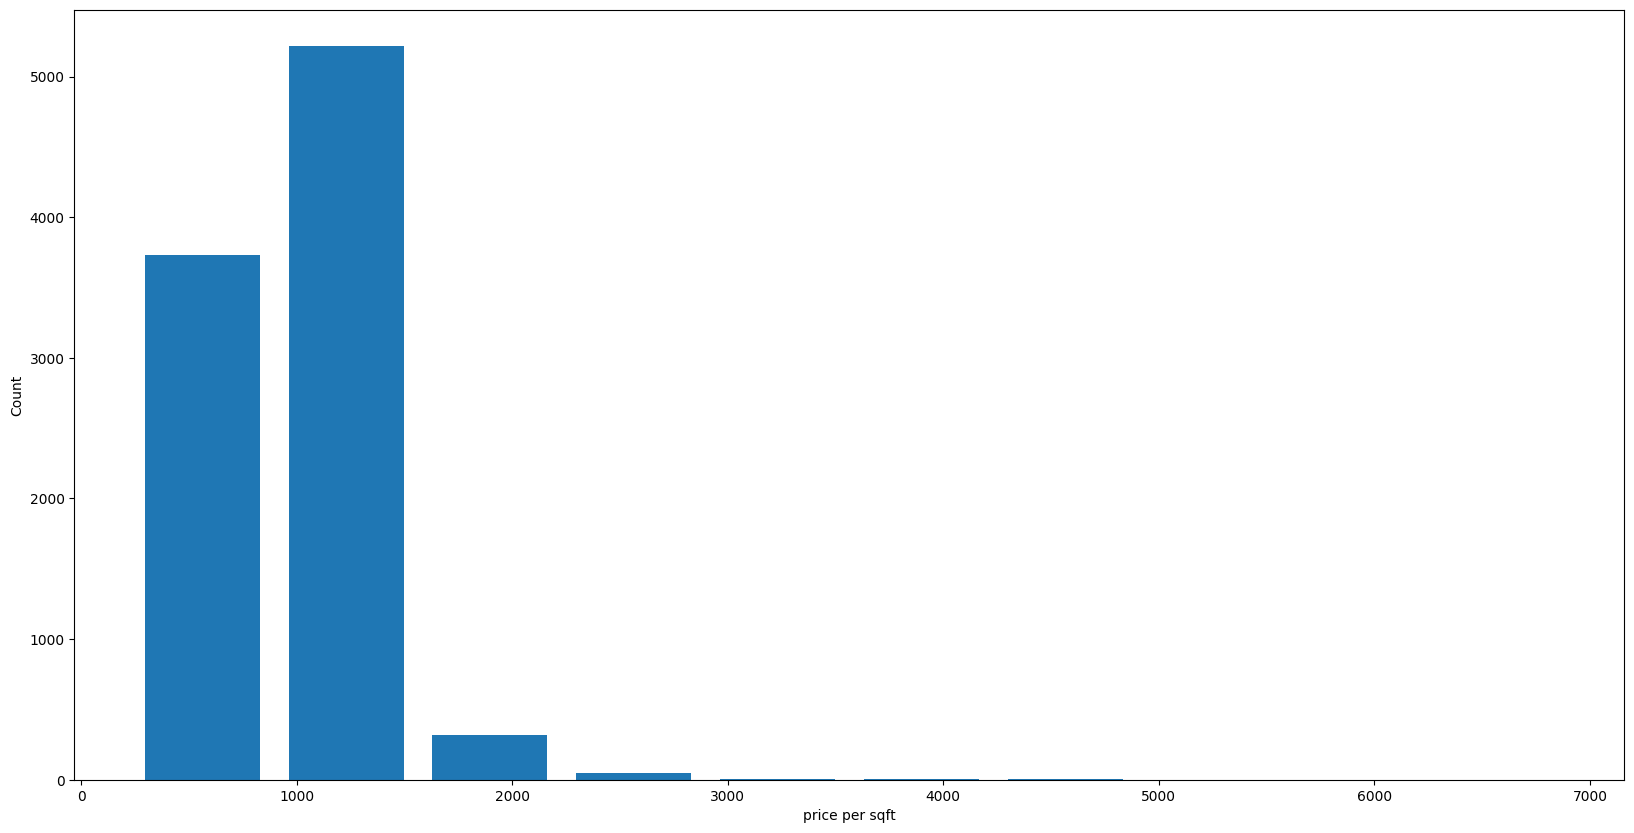

In [29]:
import matplotlib
from matplotlib import pyplot as plt

matplotlib.rcParams['figure.figsize'] = (20, 10)
plt.hist(ds_1.price_per_sqft, rwidth=0.8)
plt.xlabel("price per sqft")
plt.ylabel("Count")

In [30]:
ds_1.baths.unique()

array([ 1.,  2.,  3.,  5.,  4.,  8.,  6., 12.,  9., 22.,  7., 10., 11.])

In [31]:
ds_1[ds_1.baths>10]

,home_type,price,latitude,longitude,beds,baths,area,locality,price_per_sqft
2482,CONDO,2499000.0,43.663307,-79.371692,NaN,12.0,2665.0,moss park,937.711069
2563,CONDO,3925000.0,43.650792,-79.417718,NaN,12.0,7700.0,trinity bellwoods,509.740260
2586,CONDO,4900000.0,43.660120,-79.372828,NaN,22.0,7841.0,moss park,624.920291
2626,CONDO,5750000.0,43.706289,-79.294548,NaN,12.0,NaN,clairlea birchmount,NaN
2633,CONDO,8474000.0,43.671117,-79.297995,NaN,11.0,11232.0,the beaches,754.451567
3197,HOUSE,34500000.0,43.678844,-79.406816,6.0,11.0,5000.0,casa loma,6900.000000
3284,DUPLEX_TRIPLEX_FOURPLEX,3299000.0,43.674409,-79.432568,4.0,11.0,3250.0,wychwood,1015.076923


In [32]:
ds_1 = ds_1[ds_1.baths < 10]

In [33]:
ds_1

,home_type,price,latitude,longitude,beds,baths,area,locality,price_per_sqft
0,CONDO,388000.0,43.648879,-79.388044,1.0,1.0,350.0,waterfront communities the island,1108.571429
1,CONDO,385000.0,43.653313,-79.359882,NaN,1.0,350.0,moss park,1100.000000
2,CONDO,299000.0,43.657375,-79.374087,NaN,1.0,350.0,church yonge corridor,854.285714
3,CONDO,399000.0,43.661136,-79.385605,1.0,1.0,650.0,bay street corridor,613.846154
4,CONDO,399999.0,43.657640,-79.350917,1.0,1.0,550.0,south riverdale,727.270909
...,...,...,...,...,...,...,...,...,...
9698,CONDO,517500.0,43.652995,-79.468987,1.0,1.0,350.0,high park north,1478.571429
9699,CONDO,555000.0,43.645958,-79.389873,1.0,1.0,550.0,waterfront communities c1,1009.090909
9701,CONDO,600000.0,43.716540,-79.284514,2.0,2.0,950.0,clairlea birchmount,631.578947
9702,CONDO,595000.0,43.656969,-79.374122,1.0,1.0,550.0,moss park,1081.818182


In [34]:
toronto_ds = ds_1.drop(columns=['price_per_sqft'])

In [35]:
toronto_ds

,home_type,price,latitude,longitude,beds,baths,area,locality
0,CONDO,388000.0,43.648879,-79.388044,1.0,1.0,350.0,waterfront communities the island
1,CONDO,385000.0,43.653313,-79.359882,NaN,1.0,350.0,moss park
2,CONDO,299000.0,43.657375,-79.374087,NaN,1.0,350.0,church yonge corridor
3,CONDO,399000.0,43.661136,-79.385605,1.0,1.0,650.0,bay street corridor
4,CONDO,399999.0,43.657640,-79.350917,1.0,1.0,550.0,south riverdale
...,...,...,...,...,...,...,...,...
9698,CONDO,517500.0,43.652995,-79.468987,1.0,1.0,350.0,high park north
9699,CONDO,555000.0,43.645958,-79.389873,1.0,1.0,550.0,waterfront communities c1
9701,CONDO,600000.0,43.716540,-79.284514,2.0,2.0,950.0,clairlea birchmount
9702,CONDO,595000.0,43.656969,-79.374122,1.0,1.0,550.0,moss park


In [36]:
toronto_ds

,home_type,price,latitude,longitude,beds,baths,area,locality
0,CONDO,388000.0,43.648879,-79.388044,1.0,1.0,350.0,waterfront communities the island
1,CONDO,385000.0,43.653313,-79.359882,NaN,1.0,350.0,moss park
2,CONDO,299000.0,43.657375,-79.374087,NaN,1.0,350.0,church yonge corridor
3,CONDO,399000.0,43.661136,-79.385605,1.0,1.0,650.0,bay street corridor
4,CONDO,399999.0,43.657640,-79.350917,1.0,1.0,550.0,south riverdale
...,...,...,...,...,...,...,...,...
9698,CONDO,517500.0,43.652995,-79.468987,1.0,1.0,350.0,high park north
9699,CONDO,555000.0,43.645958,-79.389873,1.0,1.0,550.0,waterfront communities c1
9701,CONDO,600000.0,43.716540,-79.284514,2.0,2.0,950.0,clairlea birchmount
9702,CONDO,595000.0,43.656969,-79.374122,1.0,1.0,550.0,moss park


In [37]:
toronto_ds.beds.isna().sum()

np.int64(235)

In [38]:
toronto_ds = toronto_ds[toronto_ds["beds"].notna()]

In [39]:
toronto_ds = toronto_ds[toronto_ds.area.notna()]

In [40]:
toronto_ds.area.isna().sum()

np.int64(0)

In [41]:
toronto_ds.latitude.isna().sum()

np.int64(0)

In [42]:
toronto_ds.longitude.isna().sum()

np.int64(0)

In [43]:
toronto_ds.home_type.isna().sum()

np.int64(0)

In [44]:
toronto_ds.locality.isna().sum()

np.int64(1)

In [45]:
toronto_ds = toronto_ds[toronto_ds.locality.notna()]

In [46]:
toronto_ds

,home_type,price,latitude,longitude,beds,baths,area,locality
0,CONDO,388000.0,43.648879,-79.388044,1.0,1.0,350.0,waterfront communities the island
3,CONDO,399000.0,43.661136,-79.385605,1.0,1.0,650.0,bay street corridor
4,CONDO,399999.0,43.657640,-79.350917,1.0,1.0,550.0,south riverdale
5,CONDO,369000.0,43.696837,-79.293353,1.0,1.0,950.0,taylor massey
6,CONDO,399900.0,43.721194,-79.544126,3.0,2.0,1100.0,elms old rexdale
...,...,...,...,...,...,...,...,...
9698,CONDO,517500.0,43.652995,-79.468987,1.0,1.0,350.0,high park north
9699,CONDO,555000.0,43.645958,-79.389873,1.0,1.0,550.0,waterfront communities c1
9701,CONDO,600000.0,43.716540,-79.284514,2.0,2.0,950.0,clairlea birchmount
9702,CONDO,595000.0,43.656969,-79.374122,1.0,1.0,550.0,moss park


              price  latitude  longitude      beds     baths      area
price      1.000000  0.223079  -0.002504  0.596855  0.751028  0.834404
latitude   0.223079  1.000000   0.080158  0.278851  0.281898  0.290331
longitude -0.002504  0.080158   1.000000 -0.059174 -0.012715 -0.031113
beds       0.596855  0.278851  -0.059174  1.000000  0.793348  0.813457
baths      0.751028  0.281898  -0.012715  0.793348  1.000000  0.860997
area       0.834404  0.290331  -0.031113  0.813457  0.860997  1.000000


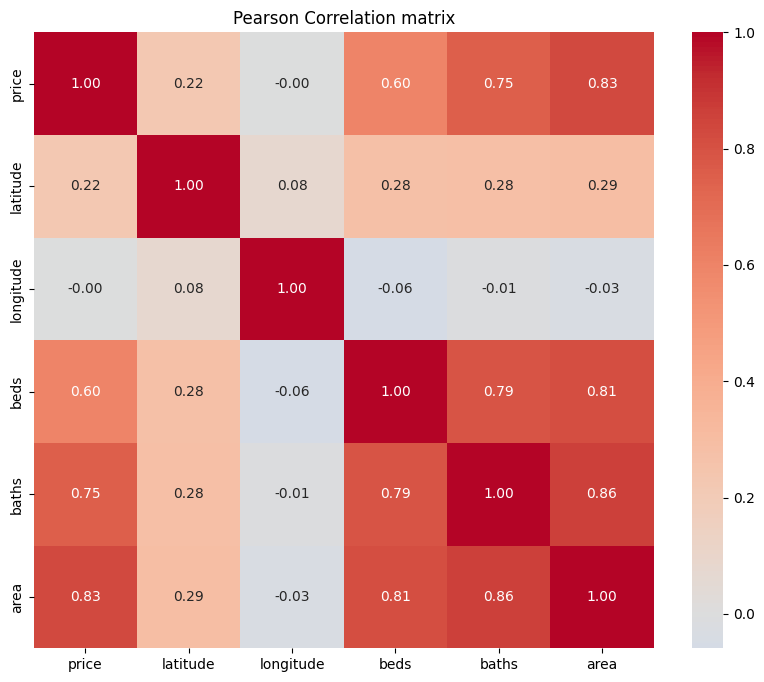

price        1.000000
area         0.834404
baths        0.751028
beds         0.596855
latitude     0.223079
longitude   -0.002504
Name: price, dtype: float64


In [47]:
# Pearson Correlation

import seaborn as sns

numeric_ds = toronto_ds.select_dtypes(include='number')

corr_matrix = numeric_ds.corr(method='pearson')
print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Pearson Correlation matrix')
plt.show()

print(corr_matrix['price'].sort_values(ascending=False))

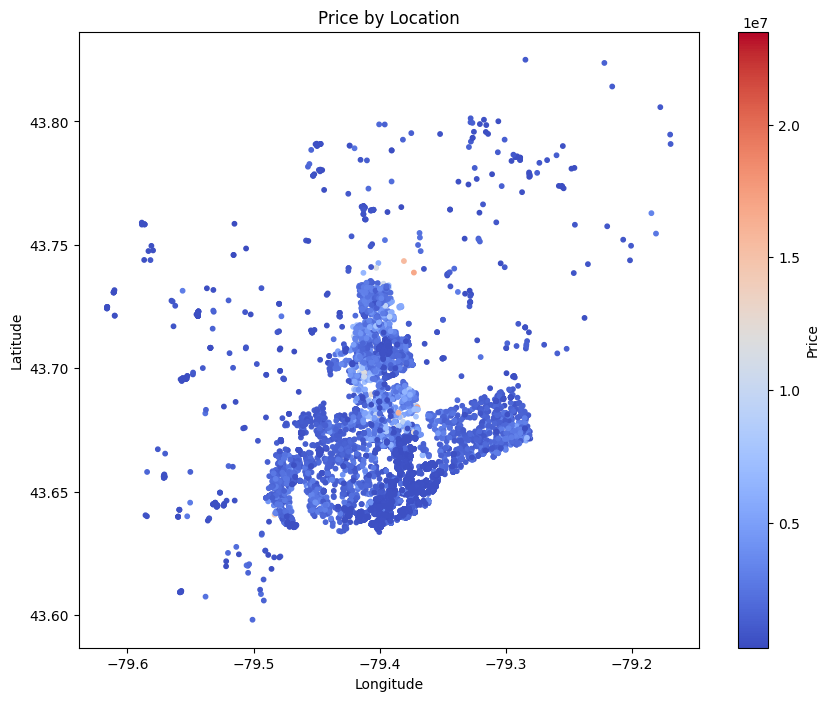

In [48]:
plt.figure(figsize=(10, 8))
plt.scatter(toronto_ds.longitude, toronto_ds.latitude, c=toronto_ds.price, cmap='coolwarm', s=10)
plt.colorbar(label='Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Price by Location')
plt.show()

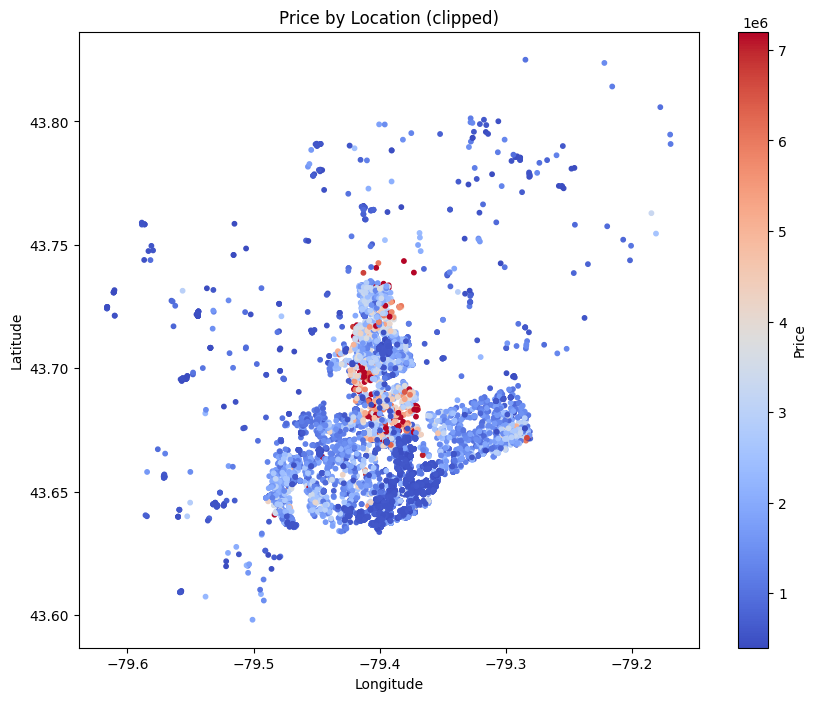

In [49]:
import numpy as np

# Clip color scale to the 1st-99th percentile to avoid outliers dominating
vmin, vmax = np.percentile(toronto_ds.price, [1, 99])

plt.figure(figsize=(10, 8))
plt.scatter(toronto_ds.longitude, toronto_ds.latitude, c=toronto_ds.price,
            cmap='coolwarm', s=10, vmin=vmin, vmax=vmax)
plt.colorbar(label='Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Price by Location (clipped)')
plt.show()

In [50]:
toronto_lr = toronto_ds.drop(columns=['latitude', 'longitude'])

In [51]:
toronto_lr = toronto_lr[~toronto_lr.home_type.isin(['TOWNHOUSE'])]

In [52]:
toronto_lr

,home_type,price,beds,baths,area,locality
0,CONDO,388000.0,1.0,1.0,350.0,waterfront communities the island
3,CONDO,399000.0,1.0,1.0,650.0,bay street corridor
4,CONDO,399999.0,1.0,1.0,550.0,south riverdale
5,CONDO,369000.0,1.0,1.0,950.0,taylor massey
6,CONDO,399900.0,3.0,2.0,1100.0,elms old rexdale
...,...,...,...,...,...,...
9698,CONDO,517500.0,1.0,1.0,350.0,high park north
9699,CONDO,555000.0,1.0,1.0,550.0,waterfront communities c1
9701,CONDO,600000.0,2.0,2.0,950.0,clairlea birchmount
9702,CONDO,595000.0,1.0,1.0,550.0,moss park


In [53]:
toronto_lr.home_type.unique()

array(['CONDO', 'HOUSE', 'DUPLEX_TRIPLEX_FOURPLEX', 'OTHER_RESIDENTIAL'],
      dtype=object)

In [54]:
ht_dummies = pd.get_dummies(toronto_lr.home_type, dtype=int)
ht_dummies

,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE,OTHER_RESIDENTIAL
0,1,0,0,0
3,1,0,0,0
4,1,0,0,0
5,1,0,0,0
6,1,0,0,0
...,...,...,...,...
9698,1,0,0,0
9699,1,0,0,0
9701,1,0,0,0
9702,1,0,0,0


In [55]:
ht_dummies = ht_dummies.drop(columns=['OTHER_RESIDENTIAL'])
ht_dummies

,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE
0,1,0,0
3,1,0,0
4,1,0,0
5,1,0,0
6,1,0,0
...,...,...,...
9698,1,0,0
9699,1,0,0
9701,1,0,0
9702,1,0,0


In [56]:
loc_dummies = pd.get_dummies(toronto_lr.locality, dtype=int)
loc_dummies

,agincourt south malvern west,annex,banbury don mills,bay street corridor,bayview woods steeles,bedford park nortown,beechborough greenbrook,bendale,birchcliffe cliffside,blake jones,...,willowdale east,willowdale west,willowridge martingrove richview,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9699,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9701,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9702,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
loc_dummies = loc_dummies.drop(columns=['other'])
loc_dummies

,agincourt south malvern west,annex,banbury don mills,bay street corridor,bayview woods steeles,bedford park nortown,beechborough greenbrook,bendale,birchcliffe cliffside,blake jones,...,willowdale east,willowdale west,willowridge martingrove richview,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9699,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9701,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9702,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [58]:
toronto_w_dummies = pd.concat([toronto_lr, ht_dummies, loc_dummies], axis='columns')
toronto_w_dummies

,home_type,price,beds,baths,area,locality,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE,agincourt south malvern west,...,willowdale east,willowdale west,willowridge martingrove richview,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park
0,CONDO,388000.0,1.0,1.0,350.0,waterfront communities the island,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CONDO,399000.0,1.0,1.0,650.0,bay street corridor,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CONDO,399999.0,1.0,1.0,550.0,south riverdale,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,CONDO,369000.0,1.0,1.0,950.0,taylor massey,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,CONDO,399900.0,3.0,2.0,1100.0,elms old rexdale,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,CONDO,517500.0,1.0,1.0,350.0,high park north,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9699,CONDO,555000.0,1.0,1.0,550.0,waterfront communities c1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9701,CONDO,600000.0,2.0,2.0,950.0,clairlea birchmount,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9702,CONDO,595000.0,1.0,1.0,550.0,moss park,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [59]:
toronto_one_hot = toronto_w_dummies.drop(columns=['home_type', 'locality'])
toronto_one_hot

,price,beds,baths,area,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE,agincourt south malvern west,annex,banbury don mills,...,willowdale east,willowdale west,willowridge martingrove richview,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park
0,388000.0,1.0,1.0,350.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,399000.0,1.0,1.0,650.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,399999.0,1.0,1.0,550.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,369000.0,1.0,1.0,950.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,399900.0,3.0,2.0,1100.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,517500.0,1.0,1.0,350.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9699,555000.0,1.0,1.0,550.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9701,600000.0,2.0,2.0,950.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9702,595000.0,1.0,1.0,550.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
X = toronto_one_hot.drop(columns=['price'])
X

,beds,baths,area,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE,agincourt south malvern west,annex,banbury don mills,bay street corridor,...,willowdale east,willowdale west,willowridge martingrove richview,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park
0,1.0,1.0,350.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1.0,1.0,650.0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1.0,1.0,550.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1.0,1.0,950.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,3.0,2.0,1100.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,1.0,1.0,350.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9699,1.0,1.0,550.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9701,2.0,2.0,950.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9702,1.0,1.0,550.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [61]:
toronto_one_hot['price_log'] = np.log(toronto_one_hot.price)


In [62]:
y = toronto_one_hot.price_log
y

0       12.868761
3       12.896717
4       12.899217
5       12.818552
6       12.898970
          ...    
9698    13.156765
9699    13.226723
9701    13.304685
9702    13.296317
9703    13.218582
Name: price_log, Length: 9075, dtype: float64

In [63]:
# Linear Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R^2 (log price): ", r2_score(y_test, y_pred))

y_pred_dollars = np.exp(y_pred)
y_test_dollars = np.exp(y_test)
print("RMSE ($): ", root_mean_squared_error(y_test_dollars, y_pred_dollars))
print("MAE: ", np.mean(np.abs(y_test_dollars - y_pred_dollars)))

R^2 (log price):  0.8553922042477051
RMSE ($):  1192693.6652585084
MAE:  335352.1206319201


In [64]:
residuals_dollars = np.abs(y_test_dollars - y_pred_dollars)
worst_idx = residuals_dollars.sort_values(ascending=False).head(10).index

# Look at these rows
toronto_one_hot.loc[worst_idx, ['price']].assign(
    predicted=np.exp(model.predict(X_test.loc[worst_idx])),
    actual_log=y_test.loc[worst_idx],
    predicted_log=model.predict(X_test.loc[worst_idx])
)

,price,predicted,actual_log,predicted_log
3288,4195900.0,4.157044e+07,15.249618,17.542900
2640,23499000.0,7.377364e+06,16.972468,15.813927
7654,4800000.0,1.492842e+07,15.384126,16.518778
8413,1500000.0,8.450223e+06,14.220976,15.949703
7717,9500000.0,1.611027e+07,16.066802,16.594968
7617,5000000.0,1.027613e+07,15.424948,16.145334
7540,3290000.0,8.164920e+06,15.006398,15.915358
3119,5290000.0,1.001556e+07,15.481329,16.119650
7498,3770000.0,8.142815e+06,15.142586,15.912647
3183,13950000.0,9.719582e+06,16.450990,16.089653


In [65]:
print((toronto_one_hot.price > 10_000_000).sum())


42


In [66]:
toronto_lr_capped = toronto_one_hot[toronto_one_hot.price <= 10_000_000]
toronto_lr_capped.shape  

(9033, 117)

In [67]:
X = toronto_lr_capped.drop(columns=['price', 'price_log'])
y = toronto_lr_capped['price_log']

In [68]:
residuals_dollars = np.abs(y_test_dollars - y_pred_dollars)
worst_idx = residuals_dollars.sort_values(ascending=False).head(10).index

toronto_lr_capped.loc[worst_idx, ['price']].assign(
    predicted=np.exp(model.predict(X_test.loc[worst_idx])),
    actual_log=y_test.loc[worst_idx],
    predicted_log=model.predict(X_test.loc[worst_idx])
)

KeyError: '[2640, 3183] not in index'

In [69]:
# GD Linear Regression

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

sgd_model = SGDRegressor(random_state=42, max_iter=20000, eta0=0.001, learning_rate='invscaling')
sgd_model.fit(X_train_scaled, y_train)

y_pred_sgd = sgd_model.predict(X_test_scaled)
y_pred_sgd_dollar = np.exp(y_pred_sgd)

print("R²: ", r2_score(y_test, y_pred_sgd))
print("RMSE ($): ", root_mean_squared_error(y_test_dollars, y_pred_sgd_dollar))

R²:  0.8555215434009305
RMSE ($):  1141271.930025187


In [70]:
# Random Forest and XG Boost

In [71]:
toronto_rf = toronto_ds[~toronto_ds.home_type.isin(['TOWNHOUSE'])]
toronto_rf = toronto_rf[toronto_rf.price <= 10_000_000]
toronto_rf

,home_type,price,latitude,longitude,beds,baths,area,locality
0,CONDO,388000.0,43.648879,-79.388044,1.0,1.0,350.0,waterfront communities the island
3,CONDO,399000.0,43.661136,-79.385605,1.0,1.0,650.0,bay street corridor
4,CONDO,399999.0,43.657640,-79.350917,1.0,1.0,550.0,south riverdale
5,CONDO,369000.0,43.696837,-79.293353,1.0,1.0,950.0,taylor massey
6,CONDO,399900.0,43.721194,-79.544126,3.0,2.0,1100.0,elms old rexdale
...,...,...,...,...,...,...,...,...
9698,CONDO,517500.0,43.652995,-79.468987,1.0,1.0,350.0,high park north
9699,CONDO,555000.0,43.645958,-79.389873,1.0,1.0,550.0,waterfront communities c1
9701,CONDO,600000.0,43.716540,-79.284514,2.0,2.0,950.0,clairlea birchmount
9702,CONDO,595000.0,43.656969,-79.374122,1.0,1.0,550.0,moss park


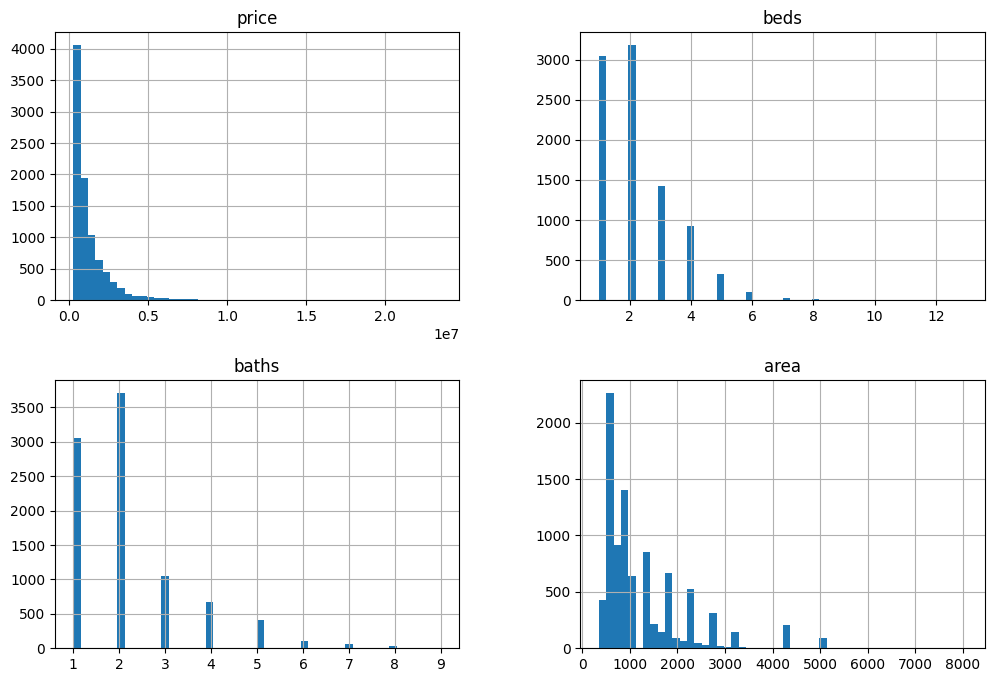

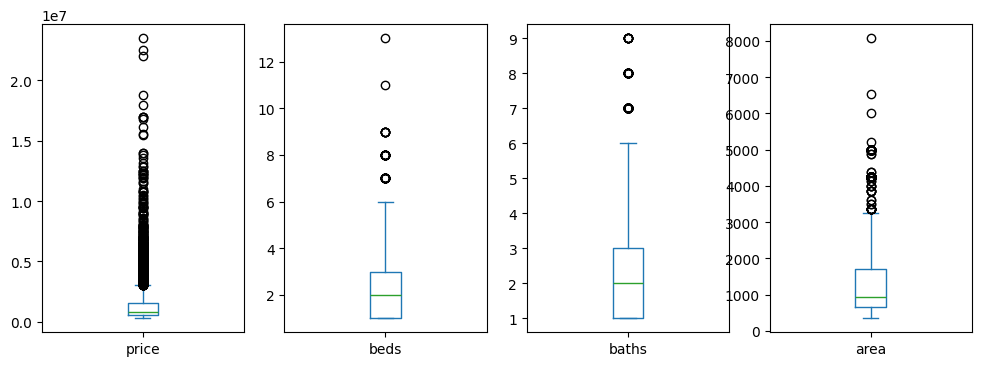

In [72]:
numeric_cols = ['price', 'beds', 'baths', 'area']
toronto_ds[numeric_cols].hist(bins=50, figsize=(12, 8))
plt.show()

toronto_ds[numeric_cols].plot(kind='box', subplots=True, figsize=(12, 4))
plt.show()

In [73]:
ht_dummies_ll = pd.get_dummies(toronto_rf.home_type, dtype=int)
ht_dummies_ll = ht_dummies_ll.drop(columns=['OTHER_RESIDENTIAL'])
ht_dummies_ll

,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE
0,1,0,0
3,1,0,0
4,1,0,0
5,1,0,0
6,1,0,0
...,...,...,...
9698,1,0,0
9699,1,0,0
9701,1,0,0
9702,1,0,0


In [74]:
loc_dummies_ll = pd.get_dummies(toronto_rf.locality, dtype=int)
loc_dummies_ll = loc_dummies_ll.drop(columns=['other'])
loc_dummies_ll

,agincourt south malvern west,annex,banbury don mills,bay street corridor,bayview woods steeles,bedford park nortown,beechborough greenbrook,bendale,birchcliffe cliffside,blake jones,...,willowdale east,willowdale west,willowridge martingrove richview,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9699,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9701,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9702,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [75]:
toronto_rf_ll = pd.concat([toronto_rf, loc_dummies_ll, ht_dummies_ll], axis='columns')
toronto_rf_ll

,home_type,price,latitude,longitude,beds,baths,area,locality,agincourt south malvern west,annex,...,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE
0,CONDO,388000.0,43.648879,-79.388044,1.0,1.0,350.0,waterfront communities the island,0,0,...,0,0,0,0,0,0,0,1,0,0
3,CONDO,399000.0,43.661136,-79.385605,1.0,1.0,650.0,bay street corridor,0,0,...,0,0,0,0,0,0,0,1,0,0
4,CONDO,399999.0,43.657640,-79.350917,1.0,1.0,550.0,south riverdale,0,0,...,0,0,0,0,0,0,0,1,0,0
5,CONDO,369000.0,43.696837,-79.293353,1.0,1.0,950.0,taylor massey,0,0,...,0,0,0,0,0,0,0,1,0,0
6,CONDO,399900.0,43.721194,-79.544126,3.0,2.0,1100.0,elms old rexdale,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,CONDO,517500.0,43.652995,-79.468987,1.0,1.0,350.0,high park north,0,0,...,0,0,0,0,0,0,0,1,0,0
9699,CONDO,555000.0,43.645958,-79.389873,1.0,1.0,550.0,waterfront communities c1,0,0,...,0,0,0,0,0,0,0,1,0,0
9701,CONDO,600000.0,43.716540,-79.284514,2.0,2.0,950.0,clairlea birchmount,0,0,...,0,0,0,0,0,0,0,1,0,0
9702,CONDO,595000.0,43.656969,-79.374122,1.0,1.0,550.0,moss park,0,0,...,0,0,0,0,0,0,0,1,0,0


In [76]:
toronto_ll = toronto_rf_ll.drop(columns=['home_type', 'locality'])
toronto_ll

,price,latitude,longitude,beds,baths,area,agincourt south malvern west,annex,banbury don mills,bay street corridor,...,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE
0,388000.0,43.648879,-79.388044,1.0,1.0,350.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,399000.0,43.661136,-79.385605,1.0,1.0,650.0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
4,399999.0,43.657640,-79.350917,1.0,1.0,550.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5,369000.0,43.696837,-79.293353,1.0,1.0,950.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6,399900.0,43.721194,-79.544126,3.0,2.0,1100.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,517500.0,43.652995,-79.468987,1.0,1.0,350.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9699,555000.0,43.645958,-79.389873,1.0,1.0,550.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9701,600000.0,43.716540,-79.284514,2.0,2.0,950.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9702,595000.0,43.656969,-79.374122,1.0,1.0,550.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [77]:
toronto_ll['price_log'] = np.log(toronto_ll.price)
toronto_ll

,price,latitude,longitude,beds,baths,area,agincourt south malvern west,annex,banbury don mills,bay street corridor,...,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE,price_log
0,388000.0,43.648879,-79.388044,1.0,1.0,350.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,12.868761
3,399000.0,43.661136,-79.385605,1.0,1.0,650.0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,12.896717
4,399999.0,43.657640,-79.350917,1.0,1.0,550.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,12.899217
5,369000.0,43.696837,-79.293353,1.0,1.0,950.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,12.818552
6,399900.0,43.721194,-79.544126,3.0,2.0,1100.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,12.898970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,517500.0,43.652995,-79.468987,1.0,1.0,350.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,13.156765
9699,555000.0,43.645958,-79.389873,1.0,1.0,550.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,13.226723
9701,600000.0,43.716540,-79.284514,2.0,2.0,950.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,13.304685
9702,595000.0,43.656969,-79.374122,1.0,1.0,550.0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,13.296317


In [78]:
X = toronto_ll.drop(columns=['price', 'price_log'])
X

,latitude,longitude,beds,baths,area,agincourt south malvern west,annex,banbury don mills,bay street corridor,bayview woods steeles,...,woburn,woodbine corridor,wychwood,yonge eglinton,yonge st clair,yonge st. clair,yorkdale glen park,CONDO,DUPLEX_TRIPLEX_FOURPLEX,HOUSE
0,43.648879,-79.388044,1.0,1.0,350.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,43.661136,-79.385605,1.0,1.0,650.0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,43.657640,-79.350917,1.0,1.0,550.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
5,43.696837,-79.293353,1.0,1.0,950.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6,43.721194,-79.544126,3.0,2.0,1100.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9698,43.652995,-79.468987,1.0,1.0,350.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9699,43.645958,-79.389873,1.0,1.0,550.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9701,43.716540,-79.284514,2.0,2.0,950.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
9702,43.656969,-79.374122,1.0,1.0,550.0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [79]:
y = toronto_ll.price_log
y

0       12.868761
3       12.896717
4       12.899217
5       12.818552
6       12.898970
          ...    
9698    13.156765
9699    13.226723
9701    13.304685
9702    13.296317
9703    13.218582
Name: price_log, Length: 9033, dtype: float64

In [80]:
# Random Forest Alg

from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_pred_dollars = np.exp(y_pred)
y_test_dollars = np.exp(y_test)

print("R² (log price): ", r2_score(y_test, y_pred))
print("RMSE ($): ", root_mean_squared_error(y_test_dollars, y_pred_dollars))
print("MAE ($): ", np.mean(np.abs(y_test_dollars - y_pred_dollars)))

R² (log price):  0.9091969344244805
RMSE ($):  470465.4049323852
MAE ($):  217303.9215497055


In [81]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best CV R²:", rf_search.best_score_)

best_rf = rf_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV R²: 0.9272340817391435
Test R²: 0.9205695115628627


In [82]:
y_pred_tuned = best_rf.predict(X_test)
y_pred_tuned_dollars = np.exp(y_pred_tuned)

print("RMSE ($): ", root_mean_squared_error(y_test_dollars, y_pred_tuned_dollars))
print("MAE ($): ", np.mean(np.abs(y_test_dollars - y_pred_tuned_dollars)))

RMSE ($):  453091.40197634016
MAE ($):  203042.77681957293


In [83]:
# XGBoost

from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

y_pred_dollars = np.exp(y_pred)
y_test_dollars = np.exp(y_test)

print("R² (log price): ", r2_score(y_test, y_pred))
print("RMSE: ($)", root_mean_squared_error(y_test_dollars, y_pred_dollars))
print("MAE: ($)", np.mean(np.abs(y_test_dollars - y_pred_dollars)))

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/opt/homebrew/Cellar/jupyterlab/4.5.1/libexec/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <09B43001-8527-34F6-AAE4-B97DA8A6CBC0> /opt/homebrew/Cellar/jupyterlab/4.5.1/libexec/lib/python3.14/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/home

In [ ]:
#XGBoost tuned
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = GradientBoostingRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

y_pred_dollars = np.exp(y_pred)
y_test_dollars = np.exp(y_test)

print("R² (log price): ", r2_score(y_test, y_pred))
print("RMSE: ($)", root_mean_squared_error(y_test_dollars, y_pred_dollars))
print("MAE: ($)", np.mean(np.abs(y_test_dollars - y_pred_dollars)))